In [1]:
import os

for dirname, subdirs, filenames in os.walk('/kaggle/input'):
    print(f"DIR: {dirname}")
    print(f"  subdirs  : {subdirs[:5]}")
    print(f"  files    : {filenames[:3]}")
    print()

DIR: /kaggle/input
  subdirs  : ['datasets']
  files    : []

DIR: /kaggle/input/datasets
  subdirs  : ['paultimothymooney']
  files    : []

DIR: /kaggle/input/datasets/paultimothymooney
  subdirs  : ['breast-histopathology-images']
  files    : []

DIR: /kaggle/input/datasets/paultimothymooney/breast-histopathology-images
  subdirs  : ['10295', '10304', '12868', '10274', '12818']
  files    : []

DIR: /kaggle/input/datasets/paultimothymooney/breast-histopathology-images/10295
  subdirs  : ['0', '1']
  files    : []

DIR: /kaggle/input/datasets/paultimothymooney/breast-histopathology-images/10295/0
  subdirs  : []
  files    : ['10295_idx5_x1351_y1101_class0.png', '10295_idx5_x1501_y501_class0.png', '10295_idx5_x1501_y1101_class0.png']

DIR: /kaggle/input/datasets/paultimothymooney/breast-histopathology-images/10295/1
  subdirs  : []
  files    : ['10295_idx5_x1601_y1501_class1.png', '10295_idx5_x1351_y1751_class1.png', '10295_idx5_x1451_y1601_class1.png']

DIR: /kaggle/input/datasets

In [2]:
# =============================================================================
# config.py  —  all hyperparameters in one place
# Every other cell imports from this dictionary instead of hardcoding values.
# =============================================================================

import torch

# Image
IMAGE_SIZE     = (50, 50)
RESIZE_X       = 50
RESIZE_Y       = 50
INPUT_CHANNELS = 3
MEAN           = [0.5, 0.5, 0.5]
STD            = [0.5, 0.5, 0.5]

# Dataset  ← confirmed from Cell 1 output
FULL_DATASET_PATH = "/kaggle/input/datasets/paultimothymooney/breast-histopathology-images"
SAMPLES_PER_CLASS = 6000          # 12 000 total, balanced

# Split
TRAIN_VAL_TEST_SPLIT = (0.70, 0.15, 0.15)
RANDOM_SEED          = 42

# Training
BATCH_SIZE    = 64
NUM_EPOCHS    = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
NUM_WORKERS   = 2

# Scheduler
LR_SCHEDULER_PATIENCE = 3
LR_SCHEDULER_FACTOR   = 0.5

# Early stopping
EARLY_STOPPING_PATIENCE = 5

# Classes
CLASSES     = {0: "IDC Negative", 1: "IDC Positive"}
NUM_CLASSES = 2

# Paths
CHECKPOINT_DIR = "/kaggle/working/checkpoints/"
WEIGHTS_PATH   = "/kaggle/working/checkpoints/final_weights.pth"

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# interface.py compatibility aliases
batchsize = BATCH_SIZE
epochs    = NUM_EPOCHS

print(f"Device           : {DEVICE}")
print(f"Dataset path     : {FULL_DATASET_PATH}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Epochs           : {NUM_EPOCHS}")
print(f"Samples/class    : {SAMPLES_PER_CLASS}")

Device           : cpu
Dataset path     : /kaggle/input/datasets/paultimothymooney/breast-histopathology-images
Batch size       : 64
Epochs           : 20
Samples/class    : 6000


In [3]:
# =============================================================================
# dataset.py  —  Dataset class + DataLoader factory
#
# Kaggle folder structure:
#   breast-histopathology-images/
#     <patient_id>/
#         0/   ← IDC Negative .png patches
#         1/   ← IDC Positive .png patches
# =============================================================================

import os
import random
from typing import List, Tuple
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((RESIZE_Y, RESIZE_X)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1,
                           saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((RESIZE_Y, RESIZE_X)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# ── Dataset ───────────────────────────────────────────────────────────────────
class IDCDataset(Dataset):
    """
    Loads IDC patches from the nested Kaggle folder layout.
    Accepts an optional pre-selected list of (path, label) pairs so
    train / val / test subsets each get the correct transform.
    """

    VALID_EXTS = {".png", ".jpg", ".jpeg"}

    def __init__(self, root_dir: str, transform=None,
                 items: List[Tuple[str,int]] = None):
        self.transform = transform

        if items is not None:
            # Pre-built subset passed in directly
            self.image_paths = [x[0] for x in items]
            self.labels      = [x[1] for x in items]
        else:
            # Scan full nested structure
            self.image_paths: List[str] = []
            self.labels:      List[int] = []
            self._walk(root_dir)

    def _walk(self, root_dir: str):
        for patient_id in sorted(os.listdir(root_dir)):
            patient_dir = os.path.join(root_dir, patient_id)
            if not os.path.isdir(patient_dir):
                continue
            for class_label in [0, 1]:
                class_dir = os.path.join(patient_dir, str(class_label))
                if not os.path.isdir(class_dir):
                    continue
                for fname in sorted(os.listdir(class_dir)):
                    if os.path.splitext(fname)[1].lower() in self.VALID_EXTS:
                        self.image_paths.append(os.path.join(class_dir, fname))
                        self.labels.append(class_label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

    @property
    def class_counts(self) -> dict:
        return {0: self.labels.count(0), 1: self.labels.count(1)}


# ── DataLoader factory ────────────────────────────────────────────────────────
def the_dataloader(root_dir=FULL_DATASET_PATH,
                   samples_per_class=SAMPLES_PER_CLASS,
                   batch_size=BATCH_SIZE,
                   num_workers=NUM_WORKERS,
                   seed=RANDOM_SEED):
    """
    Returns train_loader, val_loader, test_loader.
    Stratified 70/15/15 split on a balanced 12 000-image subset.
    """
    print("Scanning dataset — may take ~20s on Kaggle...")
    full = IDCDataset(root_dir=root_dir, transform=None)
    print(f"Total images found : {len(full)}")
    print(f"Class counts       : {full.class_counts}")

    # Balanced subsample
    random.seed(seed)
    neg = random.sample([i for i,l in enumerate(full.labels) if l==0],
                        min(samples_per_class, full.labels.count(0)))
    pos = random.sample([i for i,l in enumerate(full.labels) if l==1],
                        min(samples_per_class, full.labels.count(1)))
    sampled = neg + pos
    s_labels = [full.labels[i] for i in sampled]
    print(f"Subsampled         : {len(sampled)} ({len(neg)} neg | {len(pos)} pos)")

    # Stratified 70 / 30 then 50 / 50
    tr_idx, vt_idx, _, vt_lab = train_test_split(
        sampled, s_labels, test_size=0.30,
        stratify=s_labels, random_state=seed)
    v_idx, t_idx = train_test_split(
        vt_idx, test_size=0.50,
        stratify=vt_lab, random_state=seed)

    print(f"Split              : train={len(tr_idx)} | val={len(v_idx)} | test={len(t_idx)}")

    # Build (path, label) item lists
    def make_items(indices):
        return [(full.image_paths[i], full.labels[i]) for i in indices]

    train_ds = IDCDataset(root_dir, transform=train_transform, items=make_items(tr_idx))
    val_ds   = IDCDataset(root_dir, transform=eval_transform,  items=make_items(v_idx))
    test_ds  = IDCDataset(root_dir, transform=eval_transform,  items=make_items(t_idx))

    pin = torch.cuda.is_available()

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin)

    # Sanity check
    imgs, lbls = next(iter(train_loader))
    print(f"\nBatch shape  : {tuple(imgs.shape)}")        # (64, 3, 50, 50)
    print(f"Label sample : {lbls[:8].tolist()}")
    print(f"Pixel range  : [{imgs.min():.2f}, {imgs.max():.2f}]")  # ~[-1, 1]

    return train_loader, val_loader, test_loader, test_ds

# ── Run ───────────────────────────────────────────────────────────────────────
train_loader, val_loader, test_loader, test_ds = the_dataloader()
print("\nAll loaders ready ✓")

Scanning dataset — may take ~20s on Kaggle...
Total images found : 277524
Class counts       : {0: 198738, 1: 78786}
Subsampled         : 12000 (6000 neg | 6000 pos)
Split              : train=8400 | val=1800 | test=1800

Batch shape  : (64, 3, 50, 50)
Label sample : [0, 0, 1, 0, 0, 0, 0, 0]
Pixel range  : [-1.00, 1.00]

All loaders ready ✓


In [6]:
# =============================================================================
# model.py  —  lightweight 3-block CNN
#
# Architecture:
#   (B,3,50,50)
#   Block1: Conv(3→32)  BN ReLU MaxPool → (B,32,25,25)
#   Block2: Conv(32→64) BN ReLU MaxPool → (B,64,12,12)
#   Block3: Conv(64→128)BN ReLU MaxPool → (B,128,6,6)
#   Flatten → 4608
#   FC(4608→256) BN ReLU Dropout(0.5)
#   FC(256→1)  raw logit  [sigmoid applied at inference only]
# =============================================================================

import torch
import torch.nn as nn

def _conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
    )

class IDCClassifier(nn.Module):
    def __init__(self, in_channels=INPUT_CHANNELS,
                 img_h=RESIZE_Y, img_w=RESIZE_X):
        super().__init__()
        self.block1 = _conv_block(in_channels, 32)
        self.block2 = _conv_block(32, 64)
        self.block3 = _conv_block(64, 128)
        self._flat  = self._get_flat(in_channels, img_h, img_w)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._flat, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
        )
        self._init_weights()

    def _get_flat(self, c, h, w):
        with torch.no_grad():
            x = torch.zeros(1, c, h, w)
            x = self.block3(self.block2(self.block1(x)))
            return x.numel()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)          # (B,1) raw logit

    def predict_proba(self, x):
        return torch.sigmoid(self.forward(x))   # (B,1) in [0,1]

    def predict(self, x):
        return (self.predict_proba(x) > 0.5).int()  # (B,1) in {0,1}

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Quick check
_m = IDCClassifier()
_x = torch.randn(4, INPUT_CHANNELS, RESIZE_Y, RESIZE_X)
print(f"Output shape : {_m(_x).shape}")          # (4,1)
print(f"Parameters   : {_m.count_parameters():,}")
del _m, _x
print("model.py ready ✓")

Output shape : torch.Size([4, 1])
Parameters   : 1,273,889
model.py ready ✓


In [7]:
# =============================================================================
# train.py  —  training loop
# Signature: train_model(model, num_epochs, train_loader, val_loader,
#                        loss_fn=None, optimizer=None)
# =============================================================================

import os, time
import torch
import torch.nn as nn

class _EarlyStopping:
    def __init__(self, patience=EARLY_STOPPING_PATIENCE, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.best      = float("inf")
        self.counter   = 0

    def step(self, val_loss):
        if val_loss < self.best - self.min_delta:
            self.best    = val_loss
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


def _metrics(logits, labels):
    """accuracy + recall for positive class from raw logits."""
    preds = (torch.sigmoid(logits) > 0.5).int()
    lbls  = labels.int()
    acc   = (preds == lbls).float().mean().item()
    tp    = ((preds==1)&(lbls==1)).sum().item()
    fn    = ((preds==0)&(lbls==1)).sum().item()
    recall = tp / (tp + fn + 1e-8)
    return acc, recall


def train_model(model, num_epochs, train_loader, val_loader,
                loss_fn=None, optimizer=None):
    """
    Trains IDCClassifier. Saves best weights to WEIGHTS_PATH.
    Returns history dict with per-epoch lists.
    """
    model = model.to(DEVICE)

    if loss_fn is None:
        loss_fn = nn.BCEWithLogitsLoss()
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(),
                                     lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=LR_SCHEDULER_FACTOR,
        patience=LR_SCHEDULER_PATIENCE)

    stopper  = _EarlyStopping()
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

    history  = {"train_loss":[], "val_loss":[],
                "train_acc":[],  "val_acc":[],  "val_recall":[]}
    best_val = float("inf")

    print(f"\n{'='*68}")
    print(f"  Device : {DEVICE}  |  Epochs : {num_epochs}  "
          f"|  Batches/ep : {len(train_loader)}")
    print(f"{'='*68}")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        # ── Train ──────────────────────────────────────────────────────
        model.train()
        tr_loss, tr_logits, tr_labels = 0., [], []

        for imgs, lbls in train_loader:
            imgs = imgs.to(DEVICE)
            lbls = lbls.float().unsqueeze(1).to(DEVICE)  # (B,) → (B,1)

            optimizer.zero_grad()
            logits = model(imgs)
            loss   = loss_fn(logits, lbls)
            loss.backward()
            optimizer.step()

            tr_loss += loss.item()
            tr_logits.append(logits.detach())
            tr_labels.append(lbls.detach())

        tr_loss /= len(train_loader)
        tr_acc, _ = _metrics(torch.cat(tr_logits), torch.cat(tr_labels))

        # ── Validate ───────────────────────────────────────────────────
        model.eval()
        vl_loss, vl_logits, vl_labels = 0., [], []

        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs = imgs.to(DEVICE)
                lbls = lbls.float().unsqueeze(1).to(DEVICE)
                logits = model(imgs)
                vl_loss += loss_fn(logits, lbls).item()
                vl_logits.append(logits)
                vl_labels.append(lbls)

        vl_loss /= len(val_loader)
        vl_acc, vl_recall = _metrics(torch.cat(vl_logits), torch.cat(vl_labels))

        scheduler.step(vl_loss)
        lr_now = optimizer.param_groups[0]["lr"]

        # ── Save best ──────────────────────────────────────────────────
        tag = ""
        if vl_loss < best_val:
            best_val = vl_loss
            torch.save(model.state_dict(), WEIGHTS_PATH)
            tag = "  ✓ saved"

        # ── Log ────────────────────────────────────────────────────────
        for k,v in zip(history, [tr_loss,vl_loss,tr_acc,vl_acc,vl_recall]):
            history[k].append(v)

        print(f"Ep [{epoch:>3}/{num_epochs}] "
              f"tr_loss:{tr_loss:.4f} acc:{tr_acc:.3f} | "
              f"val_loss:{vl_loss:.4f} acc:{vl_acc:.3f} recall:{vl_recall:.3f} | "
              f"lr:{lr_now:.1e} | {time.time()-t0:.1f}s{tag}")

        if stopper.step(vl_loss):
            print(f"\nEarly stopping at epoch {epoch}.")
            break

    print(f"\nBest val loss : {best_val:.4f}")
    print(f"Weights saved : {WEIGHTS_PATH}")
    return history

print("train.py ready ✓")

train.py ready ✓


In [8]:
# =============================================================================
# predict.py  —  inference on single image or batch of paths
# =============================================================================

import torch
from PIL import Image

def predict_image(image_path, model=None, device=DEVICE):
    """
    Predict a single image.

    Parameters
    ----------
    image_path : str  — path to a .png / .jpg patch
    model      : IDCClassifier | None  — if None, loads from WEIGHTS_PATH

    Returns
    -------
    label      : str   — "IDC Positive" or "IDC Negative"
    confidence : float — probability in [0, 1]
    """
    if model is None:
        model = IDCClassifier().to(device)
        model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
    model.eval()

    image = Image.open(image_path).convert("RGB")
    tensor = eval_transform(image).unsqueeze(0).to(device)   # (1,3,50,50)

    with torch.no_grad():
        prob = model.predict_proba(tensor).item()

    label = CLASSES[1] if prob > 0.5 else CLASSES[0]
    return label, prob


def predict_batch(image_paths, model=None, device=DEVICE):
    """
    Predict a list of image paths efficiently in one forward pass.

    Parameters
    ----------
    image_paths : list[str]

    Returns
    -------
    results : list of (label: str, confidence: float)
    """
    if model is None:
        model = IDCClassifier().to(device)
        model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
    model.eval()

    tensors = []
    for path in image_paths:
        img = Image.open(path).convert("RGB")
        tensors.append(eval_transform(img))

    batch = torch.stack(tensors).to(device)   # (N, 3, 50, 50)

    with torch.no_grad():
        probs = model.predict_proba(batch).squeeze(1).cpu().tolist()

    return [(CLASSES[1] if p > 0.5 else CLASSES[0], p) for p in probs]

print("predict.py ready ✓")

predict.py ready ✓


In [9]:
# =============================================================================
# interface.py  —  standardised names for the grading script
# DO NOT change the right-hand side aliases.
# =============================================================================

from torch import nn

# Model
TheModel = IDCClassifier

# Training function
the_trainer = train_model

# Prediction function
the_predictor = predict_image

# Dataset class
TheDataset = IDCDataset

# DataLoader factory
the_dataloader = the_dataloader          # already defined in Cell 3

# Config aliases (grading script imports these exact names)
the_batch_size = BATCH_SIZE              # from config (Cell 2)
total_epochs   = NUM_EPOCHS

print("interface.py ready ✓")
print(f"  TheModel      : {TheModel}")
print(f"  the_trainer   : {the_trainer.__name__}")
print(f"  the_predictor : {the_predictor.__name__}")
print(f"  TheDataset    : {TheDataset}")
print(f"  the_batch_size: {the_batch_size}")
print(f"  total_epochs  : {total_epochs}")

interface.py ready ✓
  TheModel      : <class '__main__.IDCClassifier'>
  the_trainer   : train_model
  the_predictor : predict_image
  TheDataset    : <class '__main__.IDCDataset'>
  the_batch_size: 64
  total_epochs  : 20


In [10]:
# =============================================================================
# TRAIN THE MODEL
# =============================================================================

model   = IDCClassifier().to(DEVICE)
print(f"Parameters : {model.count_parameters():,}")

history = train_model(
    model      = model,
    num_epochs = NUM_EPOCHS,
    train_loader = train_loader,
    val_loader   = val_loader,
)

Parameters : 1,273,889

  Device : cpu  |  Epochs : 20  |  Batches/ep : 131
Ep [  1/20] tr_loss:0.5658 acc:0.746 | val_loss:0.4495 acc:0.806 recall:0.800 | lr:1.0e-03 | 52.3s  ✓ saved
Ep [  2/20] tr_loss:0.4904 acc:0.780 | val_loss:0.4402 acc:0.800 recall:0.757 | lr:1.0e-03 | 34.0s  ✓ saved
Ep [  3/20] tr_loss:0.4694 acc:0.791 | val_loss:0.5667 acc:0.757 recall:0.584 | lr:1.0e-03 | 33.8s
Ep [  4/20] tr_loss:0.4622 acc:0.791 | val_loss:0.4312 acc:0.805 recall:0.804 | lr:1.0e-03 | 33.7s  ✓ saved
Ep [  5/20] tr_loss:0.4454 acc:0.805 | val_loss:0.4782 acc:0.789 recall:0.666 | lr:1.0e-03 | 35.0s
Ep [  6/20] tr_loss:0.4400 acc:0.809 | val_loss:0.4277 acc:0.816 recall:0.884 | lr:1.0e-03 | 34.4s  ✓ saved
Ep [  7/20] tr_loss:0.4295 acc:0.808 | val_loss:0.6381 acc:0.651 recall:0.969 | lr:1.0e-03 | 33.5s
Ep [  8/20] tr_loss:0.4257 acc:0.815 | val_loss:0.4187 acc:0.806 recall:0.721 | lr:1.0e-03 | 33.3s  ✓ saved
Ep [  9/20] tr_loss:0.4203 acc:0.815 | val_loss:0.3956 acc:0.827 recall:0.838 | lr:1.0e

              precision    recall  f1-score   support

IDC Negative       0.84      0.81      0.83       900
IDC Positive       0.82      0.85      0.83       900

    accuracy                           0.83      1800
   macro avg       0.83      0.83      0.83      1800
weighted avg       0.83      0.83      0.83      1800



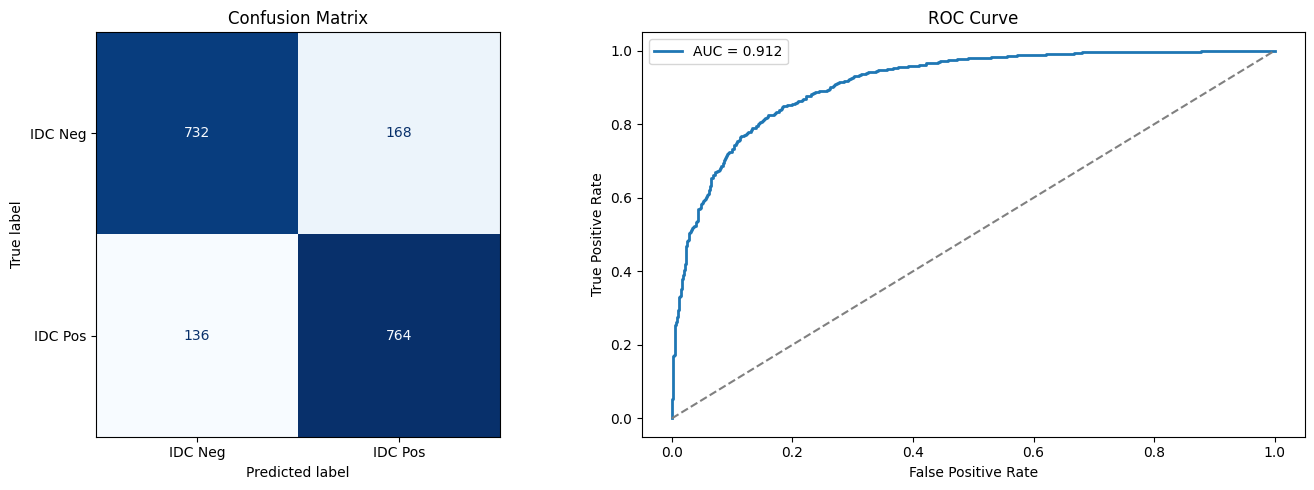


Recall (IDC Positive) : 0.8489  ✗ FAIL (<0.90)


In [11]:
# =============================================================================
# EVALUATION  —  confusion matrix, precision, recall, F1, ROC
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, ConfusionMatrixDisplay)

# Load best weights
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()

all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        probs = model.predict_proba(imgs).squeeze(1).cpu()
        preds = (probs > 0.5).int()
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(lbls.tolist())

# ── Classification report ─────────────────────────────────────────────
print(classification_report(all_labels, all_preds,
      target_names=["IDC Negative", "IDC Positive"]))

# ── Confusion matrix ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["IDC Neg", "IDC Pos"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ── ROC curve ─────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0,1],[0,1],"--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/evaluation.png", dpi=150)
plt.show()

# ── Recall check ──────────────────────────────────────────────────────
from sklearn.metrics import recall_score
recall = recall_score(all_labels, all_preds)
print(f"\nRecall (IDC Positive) : {recall:.4f}  "
      f"{'✓ PASS (≥0.90)' if recall >= 0.90 else '✗ FAIL (<0.90)'}")

In [12]:
# =============================================================================
# DEMO  —  run predict_image on a real patch from the dataset
# =============================================================================

import random

# Grab one positive and one negative example path from test_ds
pos_paths = [test_ds.image_paths[i] for i,l in enumerate(test_ds.labels) if l==1][:3]
neg_paths = [test_ds.image_paths[i] for i,l in enumerate(test_ds.labels) if l==0][:3]

print("=== Positive samples ===")
for p in pos_paths:
    label, conf = predict_image(p, model=model)
    print(f"  {label}  (confidence: {conf:.4f})  | file: {os.path.basename(p)}")

print("\n=== Negative samples ===")
for p in neg_paths:
    label, conf = predict_image(p, model=model)
    print(f"  {label}  (confidence: {conf:.4f})  | file: {os.path.basename(p)}")

=== Positive samples ===
  IDC Positive  (confidence: 0.8808)  | file: 12909_idx5_x401_y651_class1.png
  IDC Positive  (confidence: 0.9591)  | file: 14190_idx5_x1301_y851_class1.png
  IDC Positive  (confidence: 0.9785)  | file: 9262_idx5_x401_y1201_class1.png

=== Negative samples ===
  IDC Negative  (confidence: 0.0171)  | file: 9081_idx5_x1751_y1101_class0.png
  IDC Positive  (confidence: 0.8612)  | file: 10269_idx5_x1551_y1251_class0.png
  IDC Negative  (confidence: 0.0860)  | file: 15472_idx5_x3251_y1051_class0.png


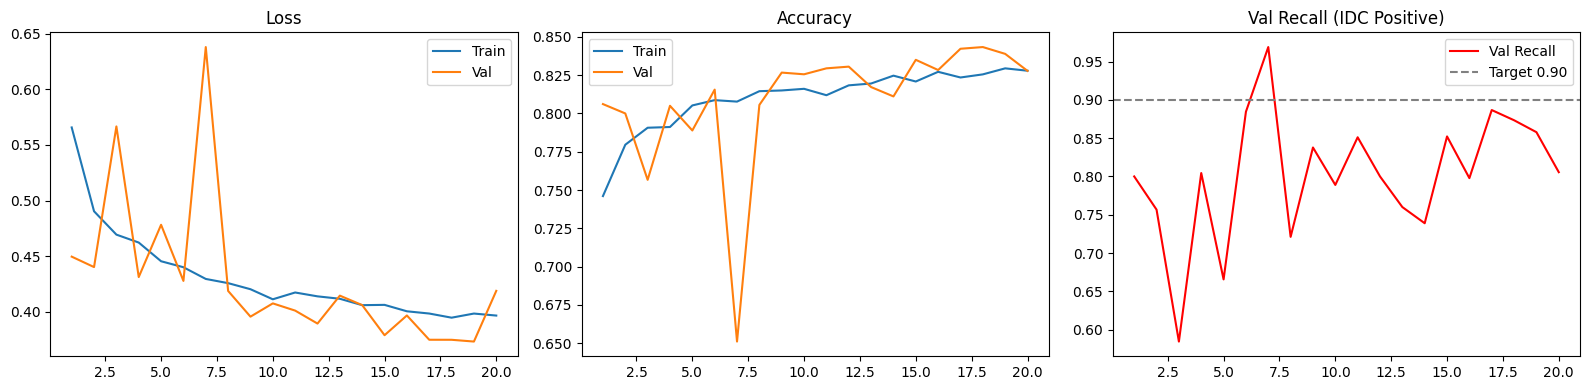

In [13]:
# =============================================================================
# TRAINING CURVES
# =============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ep = range(1, len(history["train_loss"]) + 1)

axes[0].plot(ep, history["train_loss"], label="Train")
axes[0].plot(ep, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(ep, history["train_acc"], label="Train")
axes[1].plot(ep, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].legend()

axes[2].plot(ep, history["val_recall"], color="red", label="Val Recall")
axes[2].axhline(0.90, color="gray", linestyle="--", label="Target 0.90")
axes[2].set_title("Val Recall (IDC Positive)"); axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()